   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 479.7/479.7 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.8/440.8 kB 12.6 MB/s eta 0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.12.2
    Uninstalling typing_extensions-4.12.2:
      Successfully uninstalled typing_extensions-4.12.2
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: keras
    Found existing installation: keras 3.4.1
    Uninstalling keras-3.4.1:
      Successfully uninstalled keras-3.4.1
  Attempting uninstall: gast


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 201201 entries, 2024-01-01 00:00:00 to 2024-08-02 22:00:00
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Symbol  201201 non-null  object 
 1   Open    201201 non-null  float64
 2   High    201201 non-null  float64
 3   Low     201201 non-null  float64
 4   Close   201201 non-null  float64
 5   Volume  201201 non-null  float64
dtypes: float64(5), object(1)
memory usage: 10.7+ MB
None

First few rows of the dataset:
                      Symbol      Open      High       Low     Close  \
Timestamp                                                              
2024-01-01 00:00:00  BTCUSDT  42558.02  42670.44  42520.72  42520.72   
2024-01-01 01:00:00  BTCUSDT  42520.73  42591.10  42056.00  42257.88   
2024-01-01 02:00:00  BTCUSDT  42257.89  42345.65  42066.00  42283.58   
2024-01-01 03:00:00  BTCUSDT  42283.58  42554.57  42261.02  42475.23   
2024-01-01 04:00:00  BTCUSDT  

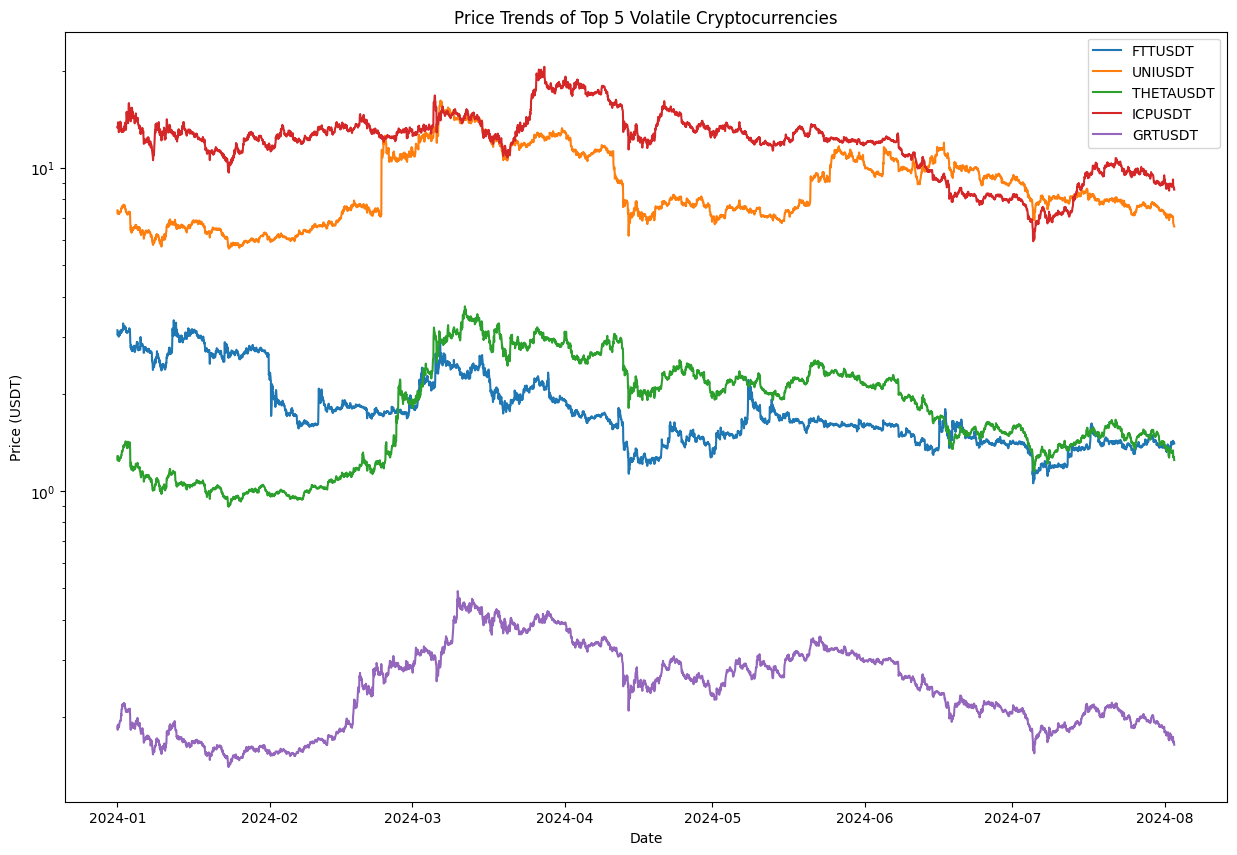

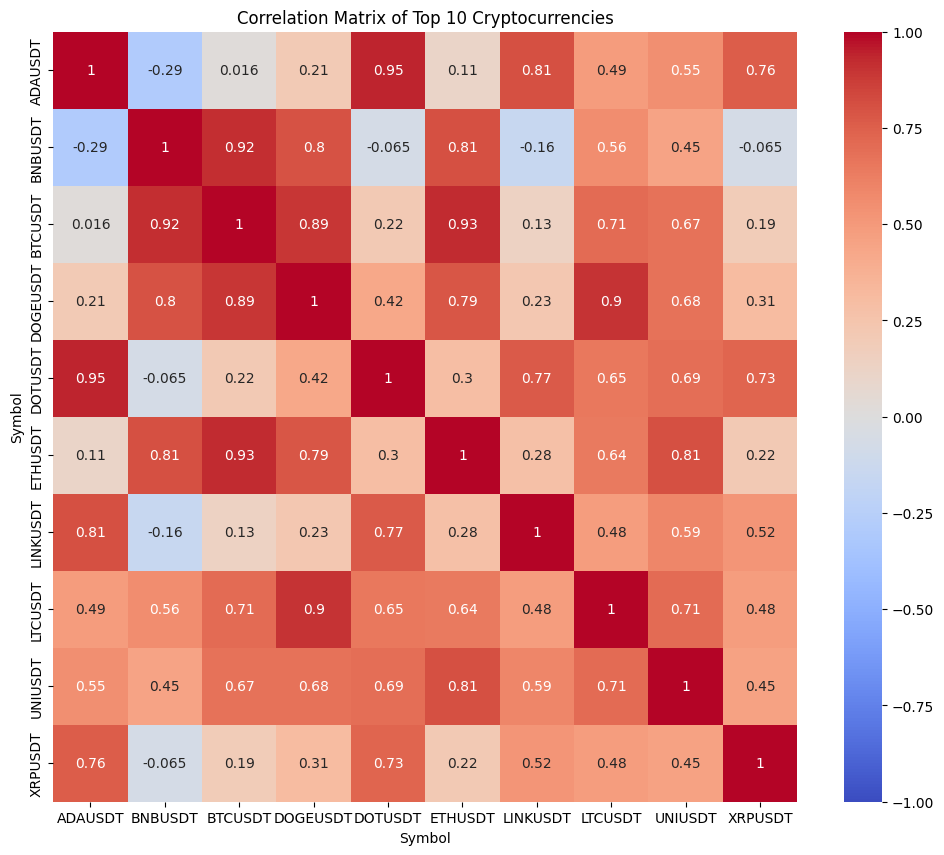

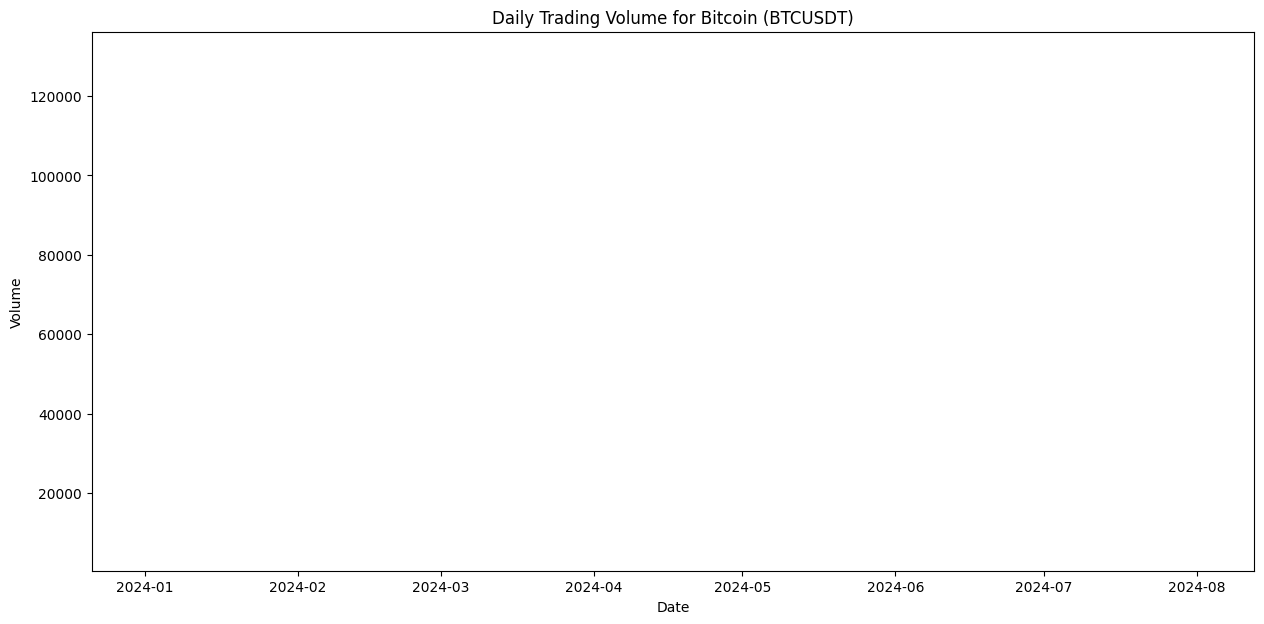


Summary Statistics for All Cryptocurrencies:
                  Open        Close         High          Low        Volume  \
Symbol                                                                        
DOGEUSDT       0.08965      0.11221      0.22888      0.07412  3.790637e+11   
XRPUSDT        0.61840      0.56190      0.74400      0.38230  9.018437e+10   
VETUSDT        0.03451      0.02459      0.05500      0.02016  8.399224e+10   
TRXUSDT        0.10883      0.12350      0.14422      0.10115  7.200118e+10   
ZILUSDT        0.02507      0.01497      0.04494      0.01306  5.893364e+10   
ADAUSDT        0.59940      0.36390      0.81040      0.31650  2.899665e+10   
XLMUSDT        0.12900      0.09410      0.16270      0.07650  1.818709e+10   
GRTUSDT        0.18730      0.16410      0.49400      0.13850  1.805061e+10   
MATICUSDT      0.98520      0.46290      1.29000      0.42810  1.739000e+10   
ALGOUSDT       0.22850      0.12470      0.32990      0.11460  1.207299e+10   
ENJUSD

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
!pip install tensorflow_decision_forests==1.5.0

import tensorflow_decision_forests as tfdf

# Read the CSV file
df = pd.read_csv("/content/drive/My Drive/Colab Notebooks/crypto_hourly_prices_2024.csv")

# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Set Timestamp as index
df.set_index('Timestamp', inplace=True)

# Display basic information about the dataset
print(df.info())

# Show the first few rows
print("\nFirst few rows of the dataset:")
print(df.head())

# Calculate daily returns
df['Daily_Return'] = df.groupby('Symbol')['Close'].pct_change()

# Calculate volatility (standard deviation of daily returns)
volatility = df.groupby('Symbol')['Daily_Return'].std().sort_values(ascending=False)

print("\nVolatility of cryptocurrencies:")
print(volatility)

# Plot price trends for top 5 cryptocurrencies by volatility
top_5_volatile = volatility.head().index

plt.figure(figsize=(15, 10))
for symbol in top_5_volatile:
    plt.plot(df[df['Symbol'] == symbol]['Close'], label=symbol)

plt.title('Price Trends of Top 5 Volatile Cryptocurrencies')
plt.xlabel('Date')
plt.ylabel('Price (USDT)')
plt.legend()
plt.yscale('log')
plt.show()

# Calculate correlation matrix for top 10 cryptocurrencies by market cap
top_10_symbols = ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'ADAUSDT', 'XRPUSDT',
                  'DOGEUSDT', 'DOTUSDT', 'UNIUSDT', 'LTCUSDT', 'LINKUSDT']

correlation_df = df[df['Symbol'].isin(top_10_symbols)].pivot(columns='Symbol', values='Close')
correlation_matrix = correlation_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Matrix of Top 10 Cryptocurrencies')
plt.show()

# Calculate and plot daily trading volume for Bitcoin
btc_data = df[df['Symbol'] == 'BTCUSDT'].copy()
btc_data.loc[:,'Daily_Volume'] = btc_data['Volume'].resample('D').sum()

plt.figure(figsize=(15, 7))
plt.plot(btc_data['Daily_Volume'])
plt.title('Daily Trading Volume for Bitcoin (BTCUSDT)')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

# Calculate and display summary statistics for all cryptocurrencies
summary_stats = df.groupby('Symbol').agg({
    'Open': 'first',
    'Close': 'last',
    'High': 'max',
    'Low': 'min',
    'Volume': 'sum'
}).sort_values('Volume', ascending=False)

summary_stats['Price_Change'] = (summary_stats['Close'] - summary_stats['Open']) / summary_stats['Open'] * 100

print("\nSummary Statistics for All Cryptocurrencies:")
print(summary_stats)


In [ ]:

# Calculate hourly returns and fill NaNs with 0 (assuming no return for the first period)
df['Hourly_Return'] = df.groupby('Symbol')['Close'].pct_change().fillna(0)

# Filter data for July (optional)
df_july = df[df.index.month == 7]

# Prepare features and target variable
features = ['Open', 'High', 'Low', 'Close', 'Volume']  # Adjust as needed
target = 'Hourly_Return'  # Now this column exists

# Convert data to TensorFlow Dataset, explicitly setting task to REGRESSION
dataset = tfdf.keras.pd_dataframe_to_tf_dataset(df[features + [target]], label=target, task = tfdf.keras.Task.REGRESSION)

# Train the model using a regressor
model = tfdf.keras.RandomForestModel(task = tfdf.keras.Task.REGRESSION) # Specify the task for the model as well
model.fit(dataset)

# Visualize the model (may not be applicable for regression)
# tfdf.model_plotter.plot_model_in_colab(model, tree_idx=0, max_depth=3)

# Display feature importances
model.make_inspector().variable_importances()

Use /tmp/tmprde1d96g as temporary training directory
Reading training dataset...
Training dataset read in 0:00:01.584634. Found 201201 examples.
Training model...
Model trained in 0:03:10.127246
Compiling model...


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: could not get source code
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: could not get source code
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Model compiled.


{'INV_MEAN_MIN_DEPTH': [("Volume" (1; #4), 0.5090919650077594),
  ("Open" (1; #3), 0.2398885862694352),
  ("Close" (1; #0), 0.2314208907249077),
  ("Low" (1; #2), 0.1462513696593613),
  ("High" (1; #1), 0.10204146055781856)],
 'NUM_AS_ROOT': [("Volume" (1; #4), 158.0),
  ("Close" (1; #0), 62.0),
  ("Open" (1; #3), 39.0),
  ("Low" (1; #2), 36.0),
  ("High" (1; #1), 5.0)],
 'NUM_NODES': [("Open" (1; #3), 21015.0),
  ("Close" (1; #0), 20186.0),
  ("Volume" (1; #4), 10978.0),
  ("Low" (1; #2), 10548.0),
  ("High" (1; #1), 10145.0)],
 'SUM_SCORE': [("Open" (1; #3), 67.5639206273195),
  ("Close" (1; #0), 52.854571845248174),
  ("Volume" (1; #4), 51.31807646509321),
  ("Low" (1; #2), 37.79619273067324),
  ("High" (1; #1), 30.00599895154449)]}

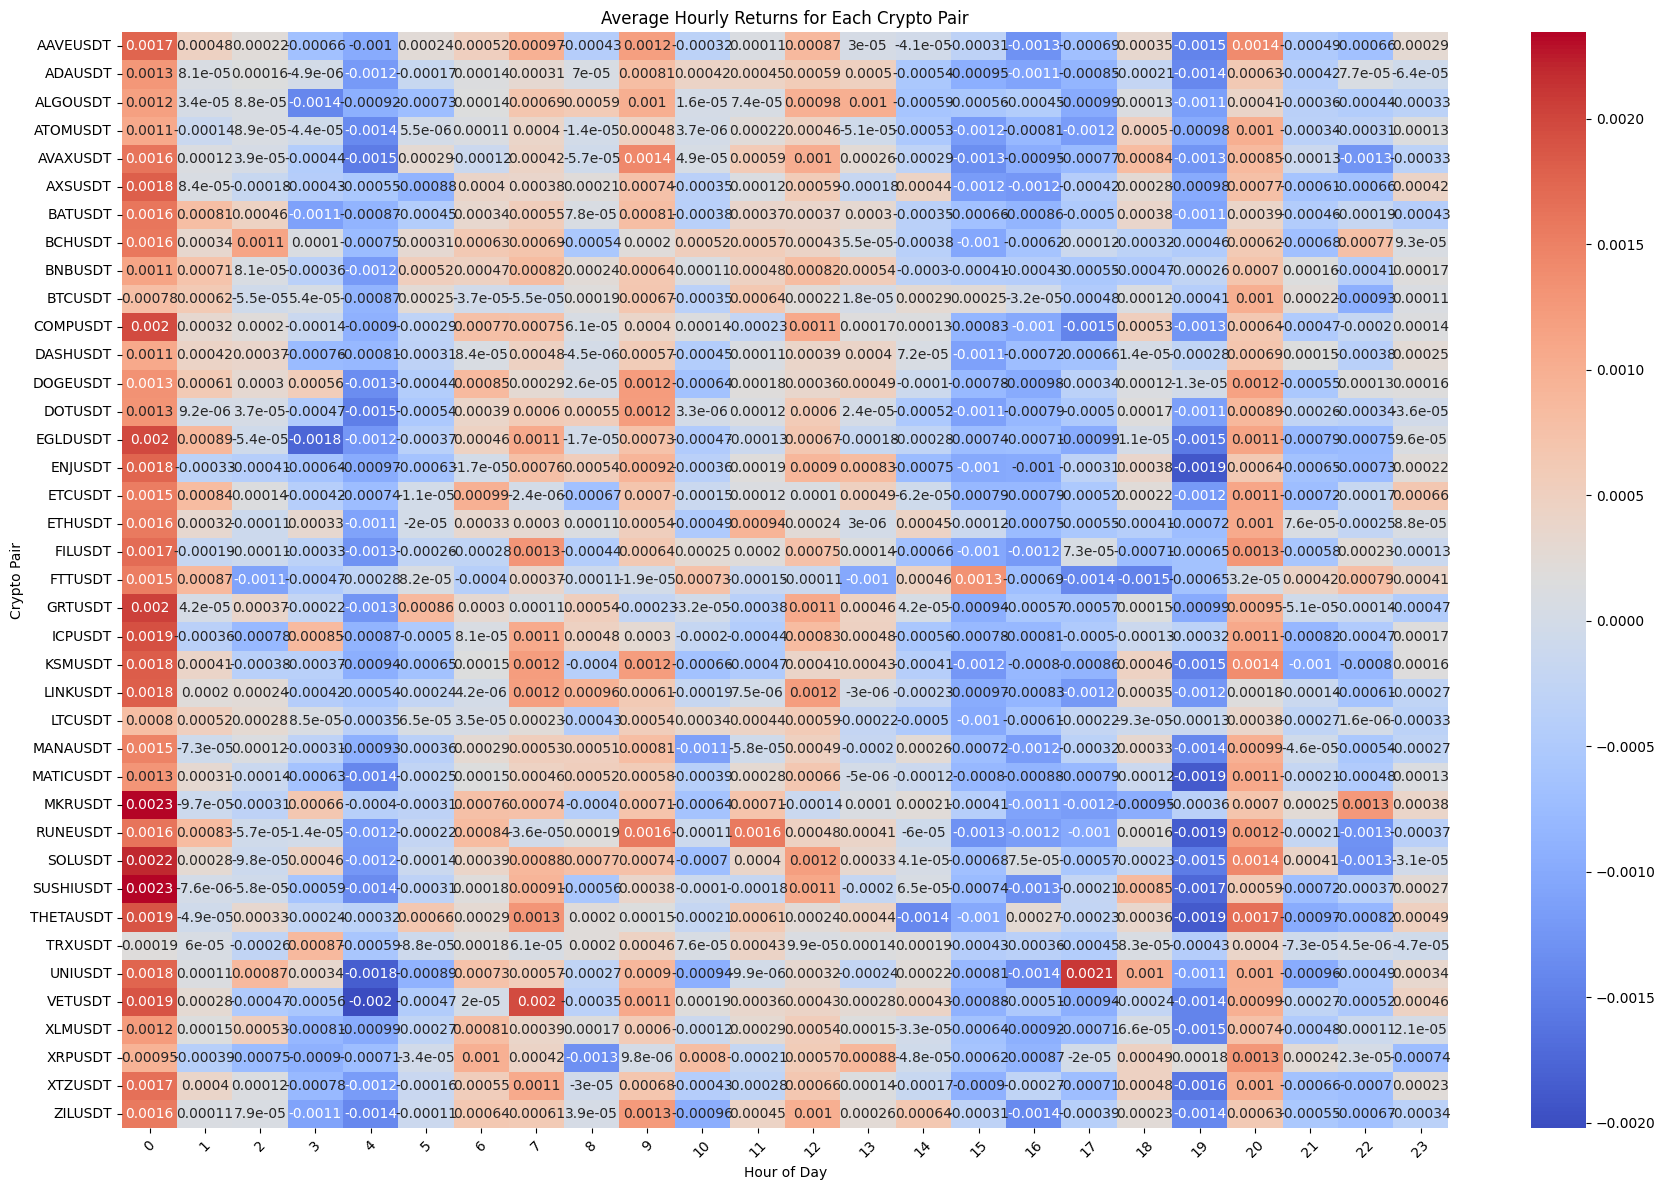

Symbol
AAVEUSDT      0
ADAUSDT       0
ALGOUSDT      0
ATOMUSDT      0
AVAXUSDT      0
AXSUSDT       0
BATUSDT       0
BCHUSDT       0
BNBUSDT       0
BTCUSDT      20
COMPUSDT      0
DASHUSDT      0
DOGEUSDT      0
DOTUSDT       0
EGLDUSDT      0
ENJUSDT       0
ETCUSDT       0
ETHUSDT       0
FILUSDT       0
FTTUSDT       0
GRTUSDT       0
ICPUSDT       0
KSMUSDT       0
LINKUSDT      0
LTCUSDT       0
MANAUSDT      0
MATICUSDT     0
MKRUSDT       0
RUNEUSDT      0
SOLUSDT       0
SUSHIUSDT     0
THETAUSDT     0
TRXUSDT       3
UNIUSDT      17
VETUSDT       7
XLMUSDT       0
XRPUSDT      20
XTZUSDT       0
ZILUSDT       0
dtype: int32
0     34
20     2
3      1
17     1
7      1
Name: count, dtype: int64


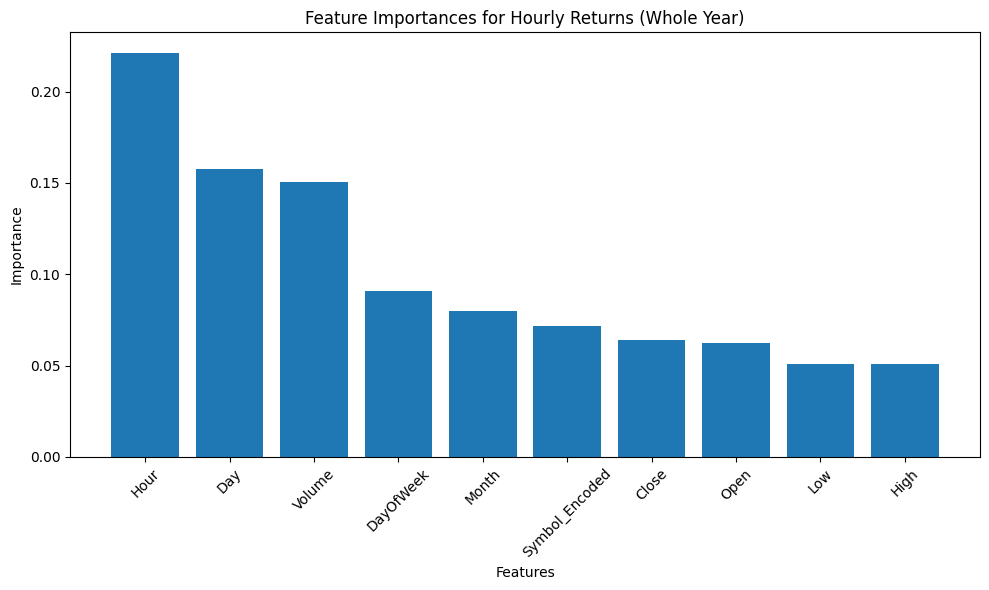

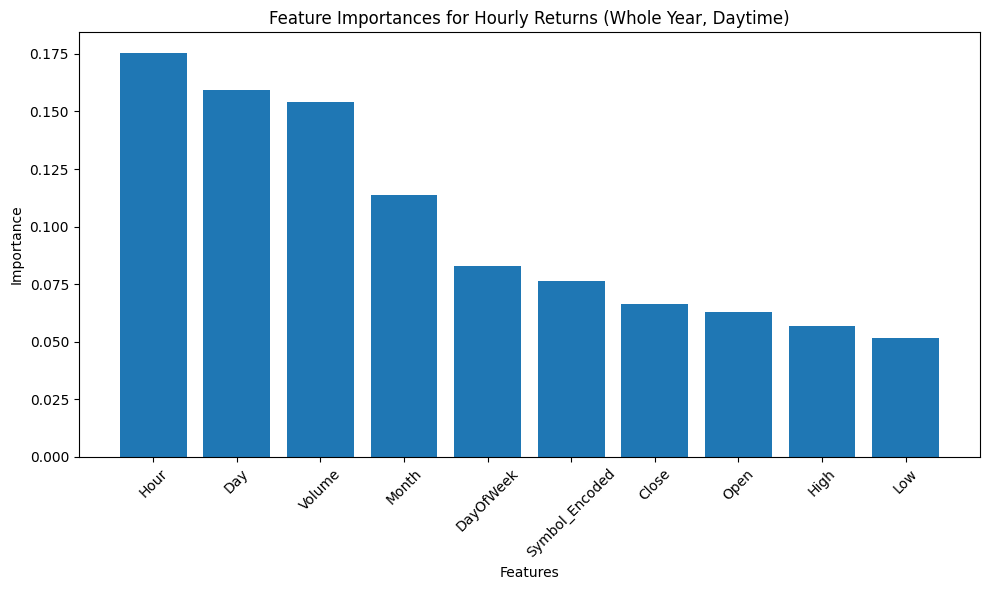

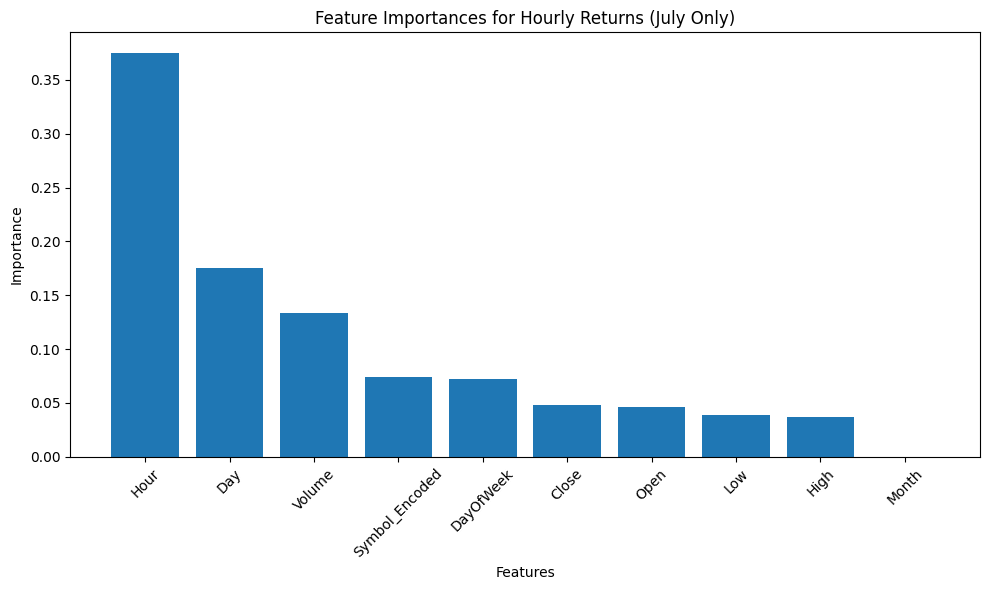

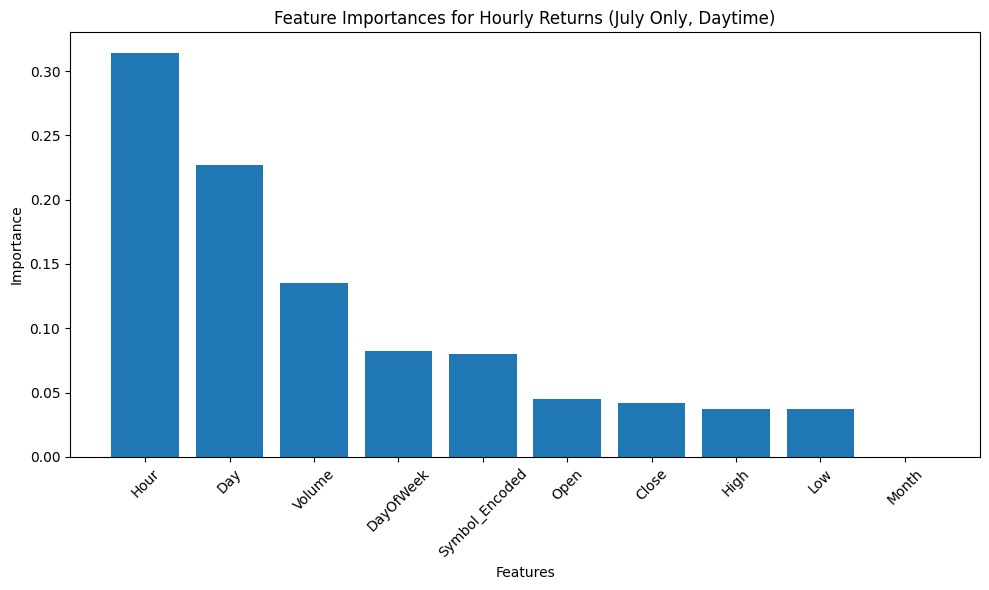

Feature Importances (Whole Year):
          feature  importance
5            Hour    0.221341
6             Day    0.157486
4          Volume    0.150528
8       DayOfWeek    0.090963
7           Month    0.080003
9  Symbol_Encoded    0.071855
3           Close    0.064018
0            Open    0.062459
2             Low    0.050727
1            High    0.050620

Feature Importances (Whole Year, Daytime):
          feature  importance
5            Hour    0.175605
6             Day    0.159349
4          Volume    0.154233
7           Month    0.113553
8       DayOfWeek    0.083071
9  Symbol_Encoded    0.076301
3           Close    0.066215
0            Open    0.063068
1            High    0.057004
2             Low    0.051601

Feature Importances (July Only):
          feature  importance
5            Hour    0.375323
6             Day    0.175316
4          Volume    0.133598
9  Symbol_Encoded    0.073716
8       DayOfWeek    0.071833
3           Close    0.048250
0            Open 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns # Import the seaborn module


# Read the CSV file
df = pd.read_csv("/content/drive/My Drive/Colab Notebooks/crypto_hourly_prices_2024.csv")

# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Set Timestamp as index
df.set_index('Timestamp', inplace=True)

# Calculate hourly returns
df['Hourly_Return'] = df.groupby('Symbol')['Close'].pct_change()

# Create additional features
df['Hour'] = df.index.hour
df['Day'] = df.index.day
df['Month'] = df.index.month
df['DayOfWeek'] = df.index.dayofweek

# Encode Symbol as numerical
le = LabelEncoder()
df['Symbol_Encoded'] = le.fit_transform(df['Symbol'])

# Function to prepare data and train model, now with daytime filtering
def train_random_forest(data, daytime_only=False):
    # Prepare features and target
    features = ['Open', 'High', 'Low', 'Close', 'Volume', 'Hour', 'Day', 'Month', 'DayOfWeek', 'Symbol_Encoded']
    X = data[features]
    y = data['Hourly_Return']

    # Filter for daytime hours (6 AM to 6 PM) if requested
    if daytime_only:
        daytime_mask = (X['Hour'] >= 6) & (X['Hour'] <= 18)
        X = X[daytime_mask]
        y = y[daytime_mask]

    # Drop rows with NaN values in BOTH features and target simultaneously
    valid_indices = ~(X.isna().any(axis=1) | y.isna())
    X = X[valid_indices]
    y = y[valid_indices]

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train Random Forest model
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)

    # Get feature importances
    importances = rf.feature_importances_
    feature_importance = pd.DataFrame({'feature': features, 'importance': importances})
    feature_importance = feature_importance.sort_values('importance', ascending=False)

    return feature_importance

# Function to calculate average hourly returns
def calculate_hourly_returns(data):
    hourly_returns = data.groupby(['Symbol', 'Hour'])['Hourly_Return'].mean().unstack(fill_value=0)
    return hourly_returns

# Calculate average hourly returns for all cryptos
hourly_returns = calculate_hourly_returns(df)

# Plot heatmap of average hourly returns with increased figure size
plt.figure(figsize=(18, 12))  # Increased figure size for better readability
sns.heatmap(hourly_returns, cmap='coolwarm', annot=True)
plt.title('Average Hourly Returns for Each Crypto Pair')
plt.xlabel('Hour of Day')
plt.ylabel('Crypto Pair')
plt.xticks(rotation=45)  # Rotate x-axis labels for better spacing
plt.yticks(rotation=0)   # Keep y-axis labels vertical for readability
plt.tight_layout()        # Adjust layout to prevent labels from overlapping
plt.show()

# Find most important hour for each crypto
most_important_hours = hourly_returns.idxmax(axis=1)
print(most_important_hours)

# Count frequency of each hour as most important
hour_counts = most_important_hours.value_counts()
print(hour_counts)

# Function to plot feature importances
def plot_feature_importances(feature_importance, title):
    plt.figure(figsize=(10, 6))
    plt.bar(feature_importance['feature'], feature_importance['importance'])
    plt.title(title)
    plt.xlabel('Features')
    plt.ylabel('Importance')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Analyze whole year
whole_year_importance = train_random_forest(df)
plot_feature_importances(whole_year_importance, 'Feature Importances for Hourly Returns (Whole Year)')

# Analyze whole year, daytime only
whole_year_daytime_importance = train_random_forest(df, daytime_only=True)
plot_feature_importances(whole_year_daytime_importance, 'Feature Importances for Hourly Returns (Whole Year, Daytime)')

# Analyze July only
july_data = df[df.index.month == 7]
july_importance = train_random_forest(july_data)
plot_feature_importances(july_importance, 'Feature Importances for Hourly Returns (July Only)')

# Analyze July, daytime only
july_daytime_importance = train_random_forest(july_data, daytime_only=True)
plot_feature_importances(july_daytime_importance, 'Feature Importances for Hourly Returns (July Only, Daytime)')

# Print feature importances
print("Feature Importances (Whole Year):")
print(whole_year_importance)
print("\nFeature Importances (Whole Year, Daytime):")
print(whole_year_daytime_importance)
print("\nFeature Importances (July Only):")
print(july_importance)
